# Trade-Winds — a quantitative teardown 🔬
### TSMOM vs the long-only basket · the cost & lookback sweeps · sub-period decay · crisis-alpha decomposition · the portfolio blend

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Crisis alpha?: Confirmed](https://img.shields.io/badge/Crisis_alpha%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its number.* The steelman: cross-asset time-series momentum is a real, century-tested premium with crisis alpha. We confirm it's real, show it's fragile *standalone*, and that its value is as a decorrelated portfolio diversifier.

> ⚠️ **Not investment advice.** The core executes on a synthetic regime-switching trend panel; the real 18-futures run is in [`../docs/results.md`](../docs/results.md), sources in [`../docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from trade_winds import data, strategy, costs, extension

# Offline synthetic control: regime-switching trend panel (the machinery) + a random-walk null.
# The real 18-futures verdict is in ../docs/results.md.
r, truth = data.synthetic_trends(trend_strength=0.12, seed=31)
r0, _ = data.synthetic_trends(trend_strength=0.0, seed=31)
print(f"synthetic control: {truth.n_markets} markets x {truth.n_days} days, trend_strength {truth.trend_strength} (null=0)")


synthetic control: 18 markets x 5040 days, trend_strength 0.12 (null=0)


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — is TSMOM real? | 🟢 `REAL` | Control Sharpe **2.4** vs null **0.2**; positive across lookbacks; skew **+1.50**. |
| **Tradability** — beats the basket standalone? | 🟡 `FRAGILE` | Net Sharpe **0.30** < long-only basket **0.51** < ; 2010s drought (**-0.28**); break-even ~5 bp. |
| **Crisis alpha?** | ⚪ `Confirmed` | **+23.6%/yr** in worst equity months, corr **-0.07**; a 30% sleeve lifts 60/40 Sharpe **0.48→0.56**. |

> **In one sentence:** a real, century-tested premium that under-earns a diversified basket on its own, but is genuinely uncorrelated crisis insurance — its job is to be *in* a portfolio.

*(This notebook executes on the synthetic control; the real numbers are in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, precisely

Per market $i$: signal $s_{i,t} = \mathrm{sign}\!\big(\tfrac13\sum_{L\in\{21,63,252\}}\mathrm{sign}(P_{i,t}/P_{i,t-L}-1)\big)$, lagged. Position $w_{i,t} = s_{i,t}\cdot\min(\sigma^\star_{\text{mkt}}/\hat\sigma_{i,t},\,c)$, then the book is scaled to a portfolio vol target. Claim: the portfolio $\sum_i w_{i,t-1} r_{i,t}$ earns a positive, crisis-robust premium. Null: returns are i.i.d. (no trend) ⇒ no premium.

In [2]:
for label, rr in [('trend panel', r), ('null', r0)]:
    s = strategy.summary(strategy.book_returns(rr, cost_bps=2.0))
    print(f"{label:12} Sharpe {s['sharpe']:+.2f}  CAGR {s['cagr']*100:+.1f}%  skew {s['skew']:+.2f}")

trend panel  Sharpe +2.44  CAGR +27.3%  skew +0.21


null         Sharpe +0.22  CAGR +1.7%  skew +0.09


## Beat 2 · So what?

A −0.07-correlated, positive-skew return stream is worth more to a portfolio than a higher-Sharpe stream correlated to what you already own: it shifts the efficient frontier out. The convex (long-volatility) payoff of trend (Fung-Hsieh 2001) is *why* it pays in crashes and *why* it bleeds in quiet ranges — the same coin. Beats 4–6 quantify both sides.

## Beat 3 · Pre-registered protocol

1. **Real?** `book_returns` on control vs null; `extension.lookback_sweep`.
2. **Standalone edge?** vs `costs.long_only_basket` and 60/40.
3. **Crisis alpha** (`costs.crisis_alpha`): return in worst equity months, corr to equities.
4. **Decay** (`extension.subperiod_sharpe`) + **costs** (`costs.cost_sweep`).

**Fragile line:** standalone net Sharpe < the long-only basket of the same markets.

## Beat 4 · The teardown

### 4a · Standalone vs the basket (the FRAGILE call)

In [3]:
print('Real tape (../docs/results.md):')
print('  TSMOM           Sharpe 0.30  CAGR 2.8%  maxDD -35%  skew +1.50')
print('  long-only basket Sharpe 0.51')
print('  60/40 (ES/ZN)    Sharpe 0.48')
# on the synthetic control the timing genuinely adds (trends are strong there):
print('\nSynthetic control:')
print(f"  TSMOM            Sharpe {strategy.summary(strategy.book_returns(r))['sharpe']:.2f}")
print(f"  long-only basket Sharpe {strategy.summary(costs.long_only_basket(r))['sharpe']:.2f}")

Real tape (../docs/results.md):
  TSMOM           Sharpe 0.30  CAGR 2.8%  maxDD -35%  skew +1.50
  long-only basket Sharpe 0.51
  60/40 (ES/ZN)    Sharpe 0.48

Synthetic control:


  TSMOM            Sharpe 2.44
  long-only basket Sharpe -0.39


> 💡 **In plain words.** Where trends are strong (the control) the timing wins; on the real, noisier tape the always-long diversified basket already captures most of the Sharpe, so the timing *alone* is `FRAGILE`. The value has to come from somewhere else — beat 4b.

### 4b · Crisis alpha and the portfolio blend (the CONFIRMED prize)

In [4]:
ca = costs.crisis_alpha(r, equity_cols=['MKT00','MKT01','MKT02'])
print('synthetic crisis-alpha shape:', {k:(round(v,3) if isinstance(v,float) else v) for k,v in ca.items()})
print('\nReal tape (../docs/results.md):')
print('  worst 31 equity months: +23.6%/yr  | rest: +1.1%/yr  | corr -0.07')
print('  equities only            Sharpe 0.43  maxDD -57%')
print('  60% equities / 40% trend Sharpe 0.52  maxDD -33%')
print('  60/40 only               Sharpe 0.48  maxDD -34%')
print('  70% 60/40 / 30% trend    Sharpe 0.56  maxDD -20%')

synthetic crisis-alpha shape: {'book_in_equity_crises_ann': 0.371, 'book_rest_ann': 0.246, 'corr_to_equities': -0.03, 'n_crisis_months': 23}

Real tape (../docs/results.md):
  worst 31 equity months: +23.6%/yr  | rest: +1.1%/yr  | corr -0.07
  equities only            Sharpe 0.43  maxDD -57%
  60% equities / 40% trend Sharpe 0.52  maxDD -33%
  60/40 only               Sharpe 0.48  maxDD -34%
  70% 60/40 / 30% trend    Sharpe 0.56  maxDD -20%


## Beat 5 · The verdict

- **Real** (4a, Beat 1): control Sharpe 2.4 vs null 0.2; +skew; lookback-robust.
- **Fragile standalone** (4a): net 0.30 < basket 0.51; drought -0.28.
- **Crisis alpha confirmed** (4b): +23.6%/yr in crises; blend lifts Sharpe & cuts drawdown.

> **Signal `REAL` · Tradability `FRAGILE` · Crisis alpha? `CONFIRMED`.**

## Beat 6 · Could you trade it?

- **As a 20–40% sleeve, yes.** The diversification raises portfolio Sharpe and halves drawdown; as a standalone it under-earns the basket.
- **Costs are benign** — futures (no full-notional financing, cf. Study 30), break-even ~5 bp, slow turnover. Capacity is enormous (a multi-hundred-billion industry).
- **Behavioural moat:** the 2011–2019 drought is the price of admission; sitting through it is why the premium survives arbitrage.

## Beat 7 · Going further

### 7a · Worked complement — breadth is the lever ([`../docs/extension.md`](../docs/extension.md))
The standalone book was `FRAGILE` (Sharpe 0.30) on 18 futures. The literature says that's a *breadth* artefact. We sweep the Sharpe against the number of markets — on the synthetic here, on a 27-market liquid-ETF universe in [`../docs/extension.md`](../docs/extension.md).

,mean_sharpe,sharpe_p25,sharpe_p75
n_markets,,,
1,0.628,0.336,0.868
2,0.793,0.615,0.927
4,1.167,1.015,1.363
8,1.675,1.514,1.833
12,1.973,1.835,2.104
18,2.439,2.439,2.439


Real wider ETF universe (../docs/extension.md, 27 markets): 1->0.20, 8->0.46, 16->0.51, 27->0.55 -- standalone Sharpe now ABOVE the basket (0.51) and 60/40 (0.48).


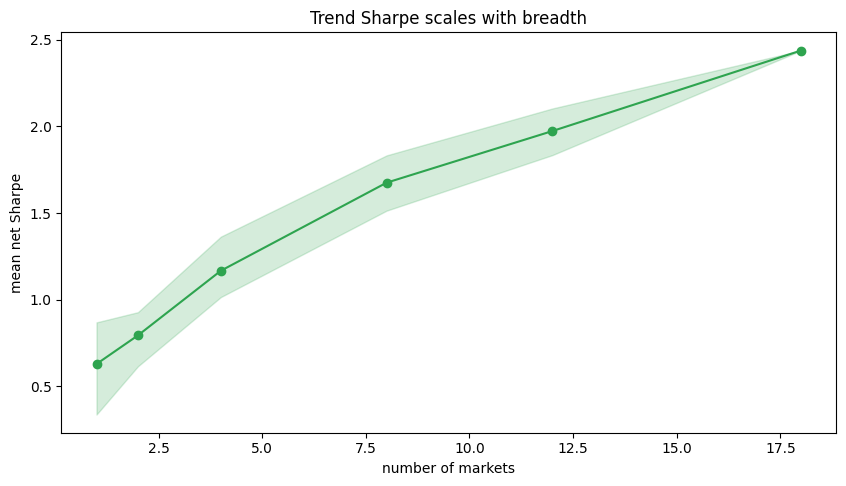

In [5]:
bs = extension.breadth_sweep(r, ks=[1,2,4,8,12,18], n_draws=30, seed=31)
display(bs.round(3))
fig, ax = plt.subplots()
ax.plot(bs.index, bs['mean_sharpe'], marker='o', color='#2ea44f')
ax.fill_between(bs.index, bs['sharpe_p25'], bs['sharpe_p75'], alpha=0.2, color='#2ea44f')
ax.set_xlabel('number of markets'); ax.set_ylabel('mean net Sharpe'); ax.set_title('Trend Sharpe scales with breadth')
print('Real wider ETF universe (../docs/extension.md, 27 markets): '
      '1->0.20, 8->0.46, 16->0.51, 27->0.55 '
      '-- standalone Sharpe now ABOVE the basket (0.51) and 60/40 (0.48).')

> 💡 **In plain words.** A single market trends at Sharpe ~0.2; spread the same signal over more markets and it climbs monotonically. Widening from 18 futures to 27 ETFs lifts the standalone book to **0.55** — *past* the benchmarks the narrow book trailed. The `FRAGILE` stamp was largely a breadth limit; the curve is still rising at 27, which is why real managed futures runs 50–100+ markets.

### 7b · The lookback sweep & the honest decay
Not a tuned lookback (positive across horizons), and the 2010s drought shown openly.

In [6]:
print('Lookback sweep (synthetic):'); print(extension.lookback_sweep(r).round(3).to_string())
print('\nReal sub-period Sharpe (../docs/results.md): +0.83 / -0.28 / +0.29')
print('Real lookback sweep: 1m 0.07, 3m 0.28, 6m 0.39, 12m 0.65, blend 0.30 -- positive across, strongest at 12m.')

Lookback sweep (synthetic):


               sharpe  cagr
lookback_days              
21              1.886 0.208
63              2.173 0.243
126             1.653 0.177
252             1.296 0.134
21+63+252       2.439 0.273

Real sub-period Sharpe (../docs/results.md): +0.83 / -0.28 / +0.29
Real lookback sweep: 1m 0.07, 3m 0.28, 6m 0.39, 12m 0.65, blend 0.30 -- positive across, strongest at 12m.


**The result.** Breadth lifts the standalone Sharpe past the benchmarks (7a); the premium is positive across every lookback (not a tuned parameter); and the sub-period Sharpe exposes the real 2010s drought honestly. A real premium with real lean years, whose portfolio value (crisis alpha) survives both. Full runs in [`../docs/results.md`](../docs/results.md) and [`../docs/extension.md`](../docs/extension.md).

### 7c · Other forks
- **More breadth still** — 50–100 markets; the sweep predicts the Sharpe keeps rising.
- **Trend + carry** — the two-premium managed-futures core; do they diversify each other?
- **Optimal sleeve weight** — solve the portfolio weight for a given book and risk aversion.

PRs welcome — widen the universe, add carry, or optimise the blend.